# Sample-based Quantum Diagonalization (SQD) - LiH
This Jupyter notebook `SQD_LiH.ipynb` and the Python file `SQD_Alain.py` are compatible with Python 3.13, Qiskit v2.1, Qiskit runtime version: 0.40 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |July 1, 2025|
|**Version:** |**1.00**<br/>*Details see at the end of this notebook*|
|**Credit:**|
This jupyter notebook is derived from the tutorial [Improving energy estimation of a chemistry Hamiltonian with SQD](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb) which is distributed under the [Apache License 2.0](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/LICENSE.txt).
|**References:**|
[Improving energy estimation of a chemistry Hamiltonian with SQD](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb)
[Sample-based Quantum Diagonalization (SQD), Quantum diagonalization algorithms](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/sqd-overview)
[Quantum diagonalization algorithms, IBM Quantum Platform, Quantum Learning](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms)
[Ieva Liepuoniute, Kirstin D. DoneyJavier Robledo MorenoJoshua A. JobWilliam S. FriendGavin O. Jones, Quantum-Centric Computational Study of Methylene Singlet and Triplet States, J. Chem. Theory Comput. 2025, 21, 10, 5062–5070](https://doi.org/10.1021/acs.jctc.5c00075)
[Antonio Mezzacapo: Quantum diagonalization methods for lattice models, IQuS - The InQubator For Quantum Simulation, Feb 19, 2025](https://www.youtube.com/watch?v=b1fhh71hY2g)
[J. Robledo-Moreno et al., "Chemistry Beyond Exact Solutions on a Quantum-Centric Supercomputer" (2024), arXiv:quant-ph/2405.05068](https://arxiv.org/abs/2405.05068)
[M. Motta et al., “Bridging physical intuition and hardware efficiency for correlated electronic states: the local unitary cluster Jastrow ansatz for electronic structure” (2023), Chem. Sci., 2023, 14, 11213](https://pubs.rsc.org/en/content/articlehtml/2023/sc/d3sc02516k)
[Quantum-Selected Configuration Interaction: classical diagonalization of Hamiltonians in subspaces selected by quantum computers, arXiv:2302.11320, quant-ph](https://doi.org/10.48550/arXiv.2302.11320)
[Introduction to Qiskit patterns](https://quantum.cloud.ibm.com/docs/en/guides/intro-to-patterns)
[Keeper L. Sharkey and Alain Chancé, Quantum Chemistry and Computing for the Curious: Illustrated with Python and Qiskit® code, Packt 2022](https://a.co/d/6YCwgPb)
[Companion Jupyter notebook for Chapter 5 of the book Quantum Chemistry and Computing for the Curious: Illustrated with Python and Qiskit® code]( https://github.com/AlainChance/Quantum-Chemistry-and-Computing-for-the-Curious/blob/main/Chapter_05_Variational_Quantum_Eigensolver_(VQE)_algorithm_V4.ipynb)
<br/>

# MIT License

Copyright (c) 2025 Alain Chancé

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

# Credit
This jupyter notebook is derived from the tutorial [Improving energy estimation of a chemistry Hamiltonian with SQD](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb) which is distributed under the [Apache License 2.0](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/LICENSE.txt).

## Find an approximation to the ground state of the  $LiH$ molecule at equilibrium in the `6-31G` basis set
We create an instance of the SQD class with $LiH$ molecule definition, `6-31G` basis set, `max_iterations = 2`, `num_batches = 5`, `samples_per_batch = 300`, `energy_tol = 3e-5`.

Qiskit version: 2.1.1
Qiskit Aer version: 0.17.1
Qiskit runtime version: 0.40.1

Run options
Backend name: None
do plot gate map:  True
Run on QPU: False

PySCF options
Basis: 6-31g
Atom configuration:  [['Li', (0.0, 0.0, 0.0)], ['H', (1.0, 0.0, 1.5474)]]
spin:  0
Symmetry:  True
Number of frozen orbitals:  0
Compute exact energy:  True

SQD options
Chemical accuracy:  0.001
Numerical tolerance for convergence of the energy:  3e-05
Numerical tolerance for convergence of the average orbital occupancies:  0.001
Limit on the number of configuration recovery iterations:  2

Eigenstate solver options
Number of batches to subsample in each configuration recovery iteration:  5
Number of bitstrings to include in each subsampled batch of bitstrings:  300
Symmetrize spin:  True
Threshold for carrying over bitstrings with large CI weight from one iteration to the next:  0.0001
Maximum number of Davidson cycles run by the eigenstate solver:  200
Seed for the pseudorandom number generator:  24
Spin

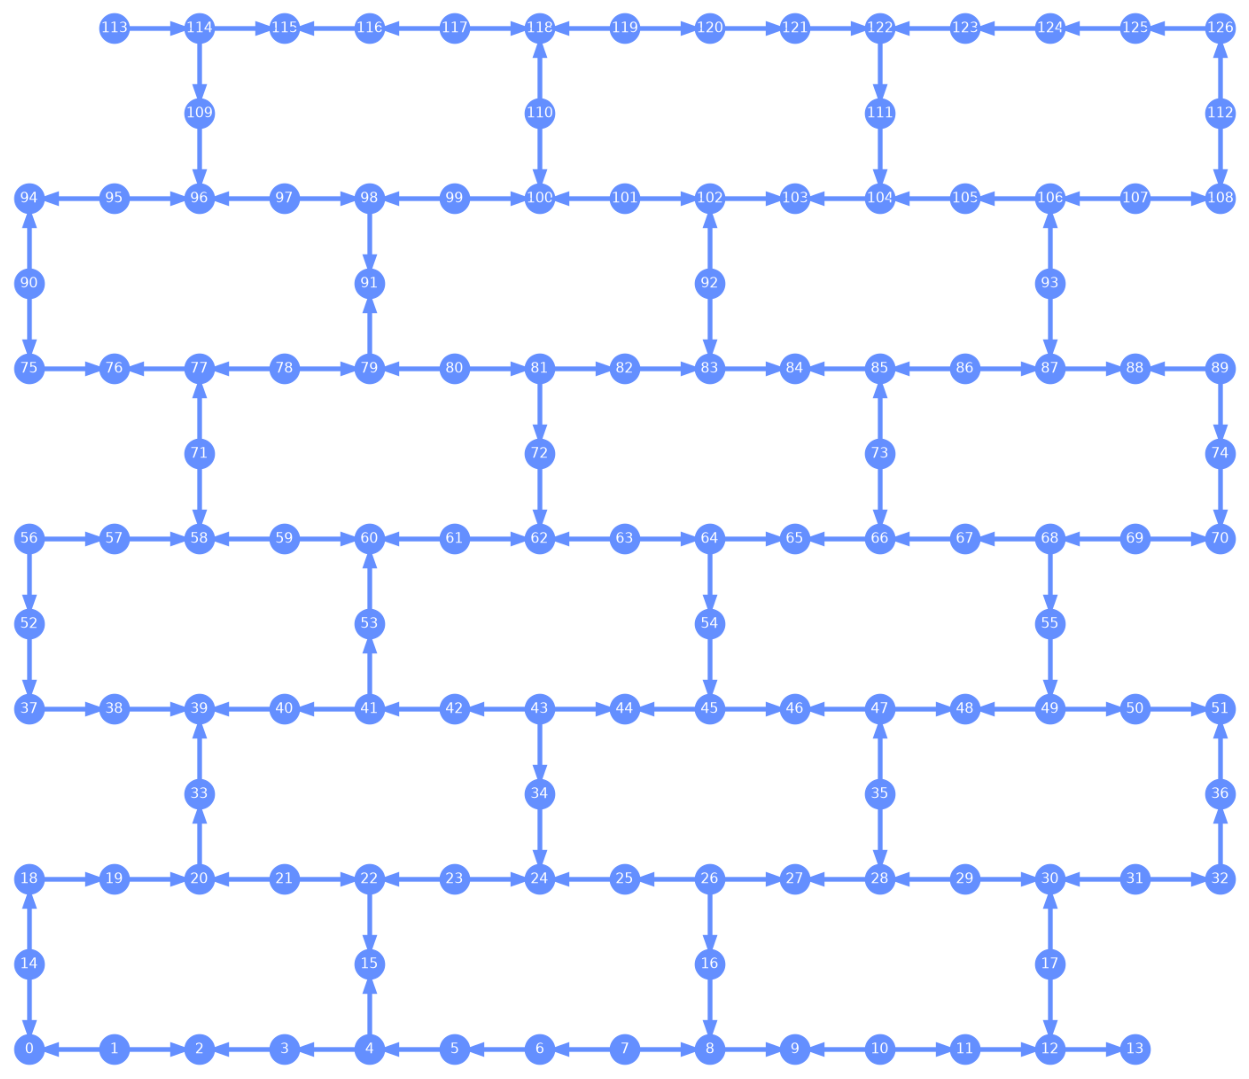

In [1]:
from SQD_Alain import SQD

SQD_LiH = SQD(
            #-------------
            # Run options
            #-------------
            backend_name = None,                                      # IBM cloud backend name
            do_plot_gate_map = True,                                  # Whether to plot the gate map 
            load_bit_array_file = None,                               # If provided, function step_3 will load samples from this file
            save_bit_array_file = None,                               # If provided, function step_3 will save samples into this file
            n_ancillary_qubits = 0,                                   # Number of ancillary qubits
            run_on_QPU = False,                                       # Whether to run the quantum circuit on the target hardware
            nshots = 1000,                                            # Number of shots
            #---------------------------------------------------------
            # PySCF options
            # https://pyscf.org/user/gto.html#initializing-a-molecule
            #---------------------------------------------------------
            basis = "6-31g",                                          # Basis set
            atom = [["Li", (0.0, 0.0, 0.0)], ["H", (1.0, 0.0, 1.5474)]],  # Atom configuration, PySCF Initializing a molecule
            symmetry = True,                                          # Point group symmetry, https://pyscf.org/user/gto.html#point-group-symmetry
            n_frozen = 0,                                             # Number of frozen orbitals
            compute_exact_energy = True,                              # Whether to compute the exact energy with PySCF, cas.run().e_tot
            #----------------------------------------------------------------------------------
            # SQD options
            # https://github.com/Qiskit/qiskit-addon-sqd/blob/main/qiskit_addon_sqd/fermion.py
            #----------------------------------------------------------------------------------
            chem_accuracy = 1e-3,                                     # Chemical accuracy (+/- 1 milli-Hartree)
            energy_tol = 3e-5,                                        # Numerical tolerance for convergence of the energy
            occupancies_tol = 1e-3,                                   # Numerical tolerance for convergence of the average orbital occupancies
            max_iterations = 2,                                       # Limit on the number of configuration recovery iterations
            #-----------------------------------------------------------------------------------
            # Eigenstate solver options
            # https://github.com/Qiskit/qiskit-addon-sqd/blob/main/qiskit_addon_sqd/fermion.py
            #-----------------------------------------------------------------------------------
            num_batches = 5,                                          # The number of batches to subsample in each configuration recovery iteration
            samples_per_batch = 300,                                  # The number of bitstrings to include in each subsampled batch of bitstrings
            symmetrize_spin = True,                                   # Whether to always merge spin-alpha and spin-beta CI strings into a single list
            carryover_threshold = 1e-4,                               # Threshold for carrying over bitstrings with large CI weight from one iteration of configuration recovery to the next
            max_cycle = 200,                                          # The maximum number of Davidson cycles run by the eigenstate solver
            seed = 24,                                                # A seed for the pseudorandom number generator
            spin_sq = 0.0)                                            # spin square

## SQD process using Qiskit patterns
Using the [Qiskit patterns](https://quantum.cloud.ibm.com/docs/en/guides/intro-to-patterns) framework, the SQD process can be described in four steps, [arXiv:2405.05068
](https://arxiv.org/abs/2405.05068):

$$\begin{array}{|c|c|c|}
\hline
\text{Step} &\text{Purpose} &\text{Method}\\
\hline
\text{1} &\text{Map classical inputs to a quantum problem} &\text{Generate an ansatz for estimating the ground state}\\
\hline
\text{2} &\text{Optimize problem for quantum execution} &\text{Transpile the ansatz for the backend}\\
\hline
\text{3} &\text{Execute experiments using Qiskit Primitives} &\text{Draw samples from the ansatz using the Sampler primitive}\\
\hline
\text{4} &\text{Post-process and return results to desired classical format} &\text{Self-consistent configuration recovery loop}\\
\hline
\end{array}$$

The probabilistic self-consistent configuration recovery is an iterative procedure that runs in a loop which comprises the following steps:
- Post-process the full set of bitstring samples, using prior knowledge of particle number and the average orbital occupancy calculated on the most recent iteration.
- Probabilistically create batches of subsamples from recovered bitstrings.
- Project and diagonalize the molecular Hamiltonian over each sampled subspace.
- Save the minimum ground state energy found across all batches and update the average orbital occupancy.

To find an approximation to the ground state of a chemistry Hamiltonian, the interacting-electron Hamiltonian takes the generic form:

$$
\hat{H} = \sum_{ \substack{pr\\\sigma} } h_{pr} \, \hat{a}^\dagger_{p\sigma} \hat{a}_{r\sigma}
+ 
\sum_{ \substack{prqs\\\sigma\tau} }
\frac{(pr|qs)}{2} \, 
\hat{a}^\dagger_{p\sigma}
\hat{a}^\dagger_{q\tau}
\hat{a}_{s\tau}
\hat{a}_{r\sigma}
$$

$\hat{a}^\dagger_{p\sigma}$ and $\hat{a}_{p\sigma}$ are the fermionic creation and annihilation operators associated with the $p$-th basis set element and spin $\sigma$. The coefficients $h{pr}$ and $(pr|qs)$ are the one- and two-electron integrals, respectively.

The SQD workflow with self-consistent configuration recovery is depicted in the following diagram.

![SQD diagram](https://raw.githubusercontent.com/Qiskit/qiskit-addon-sqd/7fcec2a686bfe115560db20b840cf2b185ae06f6/docs/_static/images/sqd_diagram.png)

Source: [Improving energy estimation of a chemistry Hamiltonian with SQD](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb)

The wave function is supported in a set of basis states $\mathcal{S} = \{|x\rangle \}$ whose size does not increase exponentially with the size of the problem. The diagonalization of the Hamiltonian projected into the subspace defined by $\mathcal{S}$ is defined as follows:
$$
H_\mathcal{S} = P_\mathcal{S} H  P_\mathcal{S} \textrm{ with } P_\mathcal{S} = \sum_{x \in \mathcal{S}} |x \rangle \langle x |;
$$
$H_\mathcal{S}$ yields a good approximation to the target eigenstate. The quantum computing device produces samples of the members of $\mathcal{S}$ only. A quantum circuit prepares the state $|\Psi\rangle$ in the quantum device. The Jordan-Wigner encoding is used, hence members of the computational basis represent Fock states (electronic configurations/determinants). The quantum circuit is sampled in the computational basis, yielding the set of noisy configurations $\tilde{\mathcal{X}}$. The configurations are represented by bitstrings. The set $\tilde{\mathcal{X}}$ is then passed into the classical post-processing block, where the [self-consistent configuration recovery technique](https://arxiv.org/abs/2405.05068) is used.

## Step 1: Map classical inputs to a quantum problem
We perform a CCSD calculation in the following code cell. The [$t_1$ and $t_2$ amplitudes](https://en.wikipedia.org/wiki/Coupled_cluster#Cluster_operator) from this calculation will be used to initialize the parameters of the `LUCJ` ansatz circuit.

We use [ffsim](https://github.com/qiskit-community/ffsim) to create the ansatz circuit. Since our molecule has a closed-shell Hartree-Fock state, we use the spin-balanced variant of the unitary cluster Jastrow (UCJ) ansatz, ffsim class [UCJOpSpinBalanced](https://qiskit-community.github.io/ffsim/api/ffsim.html#ffsim.UCJOpSpinBalanced).

ffsim is a software library for simulating fermionic quantum circuits that conserve particle number and the Z component of spin. This category includes many quantum circuits used for quantum chemistry simulations. By exploiting the symmetries and using specialized algorithms, ffsim can simulate these circuits much faster than a generic quantum circuit simulator.

converged SCF energy = -7.97560630718125
Number of spatial orbitals:  11
Number of spin orbitals:  22
Number of electrons:  4
Number of α-spin electrons:  2
Number of β-spin electrons:  2
CASCI E = -7.99654035515630  E(CI) = -8.85820423280305  S^2 = 0.0000000
exact energy:  -7.9965403551562995
E(CCSD) = -7.996527824220488  E_corr = -0.02092151703923839




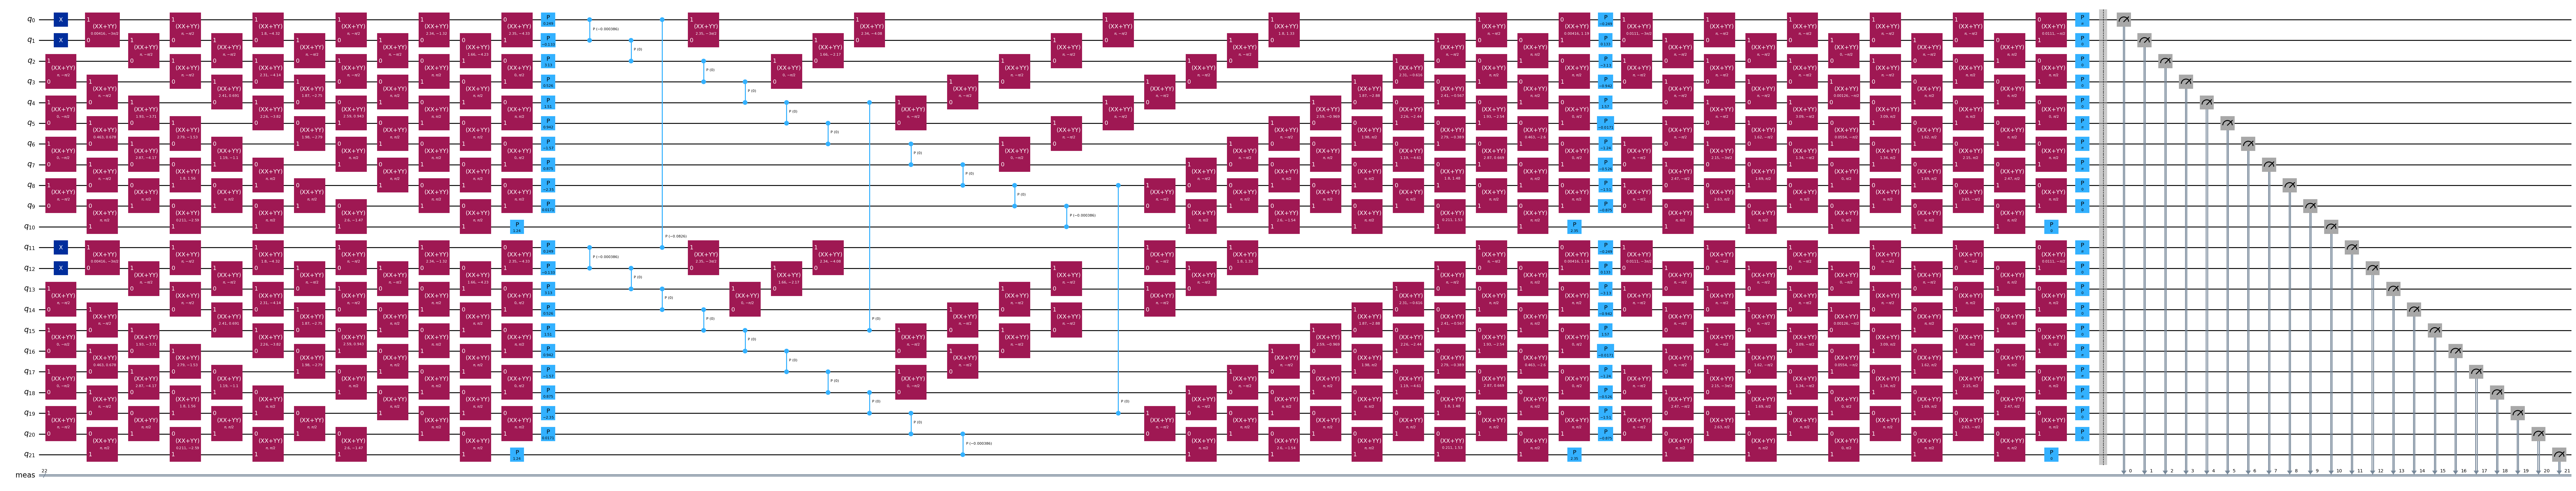

In [2]:
circuit = SQD_LiH.step_1()

## Step 2: Optimize problem for quantum execution
Next, we optimize the circuit for a target hardware. We generate a staged pass manager using the [generate\_preset\_pass\_manager](https://docs.quantum.ibm.com/api/qiskit/transpiler_preset#generate_preset_pass_manager) function from qiskit with the specified `backend` and `initial_layout`.

We set the `pre_init` stage of the staged pass manager to `ffsim.qiskit.PRE_INIT`. It includes qiskit transpiler passes that decompose gates into orbital rotations and then merges the orbital rotations, resulting in fewer gates in the final circuit.

In [3]:
isa_circuit = SQD_LiH.step_2()

Generating a staged pass manager with initial_layout = spin_a_layout + spin_b_layout
Gate counts (w/ pre-init passes): OrderedDict({'rz': 1741, 'sx': 1287, 'ecr': 530, 'x': 99, 'measure': 22, 'barrier': 1})


## Step 3: Execute using Qiskit Primitives
As shown in the tutorial [Improving energy estimation of a chemistry Hamiltonian with SQD](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb), we can use `Fake_Sherbrooke`, a fake 127-qubit backend from `qiskit_ibm_runtime` to emulate a real device, and generate random samples drawn from the uniform distribution. This approach is however not recommended, see [A case against uniform sampling](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/sqd-overview#32-a-case-against-uniform-sampling).

In [4]:
bit_array = SQD_LiH.step_3()

Generating 10k samples drawn from the uniform distribution.


## Step 4: Post-process and return result to desired classical format
The first iteration of the self-consistent configuration recovery procedure uses the raw samples, after post-selection on symmetries, as input to the diagonalization process to obtain an estimate of the average orbital occupancies.

Subsequent iterations use these occupancies to generate new configurations from raw samples that violate the symmetries (i.e., are incorrect). These configurations are collected and then subsampled to produce batches, which are subsequently used to project the Hamiltonian and compute a ground-state estimate using an eigenstate solver.

We use the `diagonalize_fermionic_hamiltonian` function defined in [qiskit-addon-sqd/qiskit\_addon\_sqd/fermion.py](https://github.com/Qiskit/qiskit-addon-sqd/blob/main/qiskit_addon_sqd/fermion.py).

The solver included in the SQD addon uses PySCF's implementation of selected CI, specifically [pyscf.fci.selected_ci.kernel_fixed_space](https://pyscf.org/pyscf_api_docs/pyscf.fci.html#pyscf.fci.selected_ci.kernel_fixed_space)

The following parameters are user-tunable:
* `max_iterations`: Limit on the number of configuration recovery iterations.
* `num_batches`: The number of batches of configurations to subsample (i.e., the number of separate calls to the eigenstate solver).
* `samples_per_batch`: The number of unique configurations to include in each batch.
* `max_cycles`: The maximum number of Davidson cycles run by the eigenstate solver.
* `occupancies_tol`: Numerical tolerance for convergence of the average orbital occupancies. If the maximum change in absolute value of the average occupancy of an orbital between iterations is smaller than this value, then the configuration recovery loop will exit, if the energy has also converged (see the ``energy_tol`` argument).
* `energy_tol`: Numerical tolerance for convergence of the energy. If the change in energy between iterations is smaller than this value, then the configuration recovery loop will exit, if the occupancies have also converged (see the ``occupancies_tol`` argument).


In [5]:
result, result_history = SQD_LiH.post_process()

Iteration 1
	Subsample 0
		Energy: -7.34627103391963
		Subspace dimension: 144
	Subsample 1
		Energy: -7.34627103391963
		Subspace dimension: 144
	Subsample 2
		Energy: -7.34627103391963
		Subspace dimension: 144
	Subsample 3
		Energy: -7.34627103391963
		Subspace dimension: 144
	Subsample 4
		Energy: -7.34627103391963
		Subspace dimension: 144
Iteration 2
	Subsample 0
		Energy: -7.996540355389263
		Subspace dimension: 3025
	Subsample 1
		Energy: -7.996540355389263
		Subspace dimension: 3025
	Subsample 2
		Energy: -7.996540355389263
		Subspace dimension: 3025
	Subsample 3
		Energy: -7.996540355389263
		Subspace dimension: 3025
	Subsample 4
		Energy: -7.996540355389263
		Subspace dimension: 3025


Exact energy: -7.99654 Ha
SQD energy: -7.99654 Ha
Absolute error: 0.00000 Ha


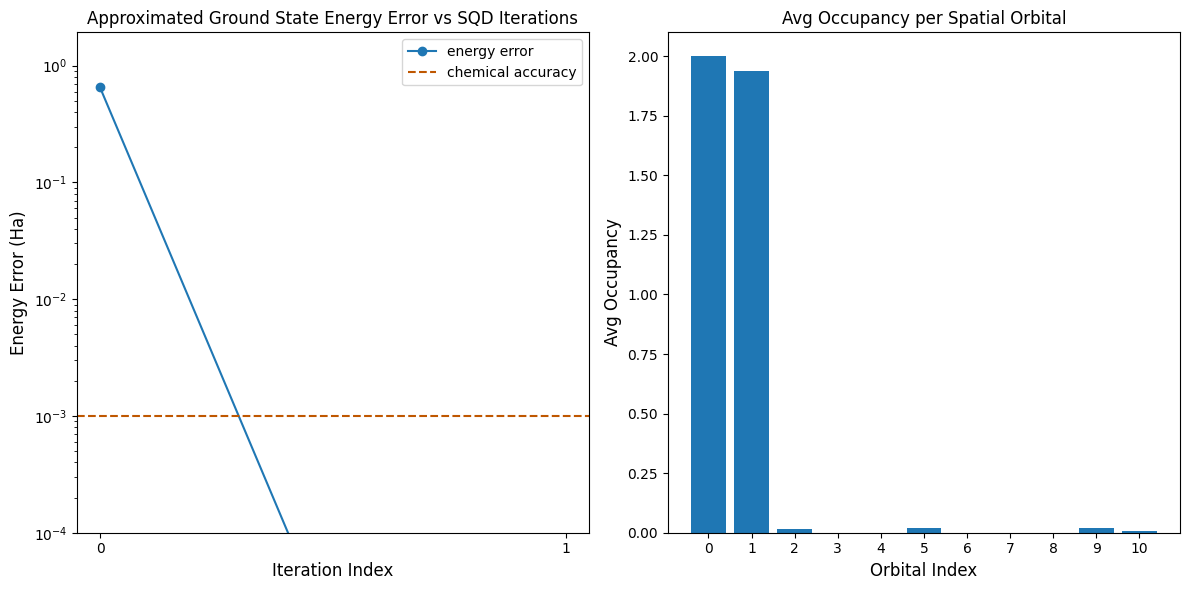

None

In [6]:
plt = SQD_LiH.plot_energy_and_occupancy()

The first plot shows an estimation of the ground state energy within $\approx$ `1 milli-Hartree (mHa)`. The usual chemical accuracy is typically defined as `1 kcal/mol` $\approx$ `1.6 mHa`. However in the context of quantum chemistry, chemical accuracy is often approximated as `1 mHa`. The estimation of the energy can be improved by drawing more samples from the circuit, increasing the number of samples per batch and increasing the number of iterations.

The second plot shows the average occupancy of each spatial orbital after the final iteration. Both the spin-up and spin-down electrons occupy the first two orbitals with high probability.

# References

[1] Improving energy estimation of a chemistry Hamiltonian with SQD, https://github.com/Qiskit/qiskit-addon-sqd/blob/main/docs/tutorials/01_chemistry_hamiltonian.ipynb

[2] Sample-based Quantum Diagonalization (SQD), Quantum diagonalization algorithms, https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/sqd-overview

[3] Quantum diagonalization algorithms, IBM Quantum Platform, Quantum Learning, https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms

[4] Antonio Mezzacapo: Quantum diagonalization methods for lattice models, IQuS - The InQubator For Quantum Simulation, Feb 19, 2025, https://www.youtube.com/watch?v=b1fhh71hY2g

[5] Ieva Liepuoniute, Kirstin D. DoneyJavier Robledo MorenoJoshua A. JobWilliam S. FriendGavin O. Jones, Quantum-Centric Computational Study of Methylene Singlet and Triplet States, J. Chem. Theory Comput. 2025, 21, 10, 5062–5070, https://doi.org/10.1021/acs.jctc.5c00075

[6] J. Robledo-Moreno et al., "Chemistry Beyond Exact Solutions on a Quantum-Centric Supercomputer" (2024), [arXiv:quant-ph/2405.05068](https://arxiv.org/abs/2405.05068)] 

[7] M. Motta et al., “Bridging physical intuition and hardware efficiency for correlated electronic states: the local unitary cluster Jastrow ansatz for electronic structure” (2023). [Chem. Sci., 2023, 14, 11213](https://pubs.rsc.org/en/content/articlehtml/2023/sc/d3sc02516k)

[8] Keita Kanno, Masaya Kohda, Ryosuke Imai, Sho Koh, Kosuke Mitarai, Wataru Mizukami, Yuya O. Nakagawa, Quantum-Selected Configuration Interaction: classical diagonalization of Hamiltonians in subspaces selected by quantum computers, arXiv:2302.11320 [quant-ph], https://doi.org/10.48550/arXiv.2302.11320

[9] Introduction to Qiskit patterns, https://quantum.cloud.ibm.com/docs/en/guides/intro-to-patterns

[10] Keeper L. Sharkey and Alain Chancé, Quantum Chemistry and Computing for the Curious: Illustrated with Python and Qiskit® code, Packt 2022, https://a.co/d/6YCwgPb

[11] Companion Jupyter notebook for Chapter 5 of the book Quantum Chemistry and Computing for the Curious: Illustrated with Python and Qiskit® code, https://github.com/AlainChance/Quantum-Chemistry-and-Computing-for-the-Curious/blob/main/Chapter_05_Variational_Quantum_Eigensolver_(VQE)_algorithm_V4.ipynb

## Qiskit packages versions

In [7]:
import qiskit
import qiskit_ibm_runtime
import qiskit_aer

print(f'Qiskit: {qiskit.__version__}')
print(f'Qiskit IBM Runtime: {qiskit_ibm_runtime.__version__}')
print(f"Qiskit Aer version: {qiskit_aer.__version__}")

Qiskit: 2.1.1
Qiskit IBM Runtime: 0.40.1
Qiskit Aer version: 0.17.1


## Show Python version

In [8]:
%%bash
which python
python --version

/home/alain/miniconda3/bin/python
Python 3.13.5
